<a href="https://colab.research.google.com/github/hsmu-jinhyeong/deep-learning-practice/blob/main/easy_deep_learning_principle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2장. 딥러닝 핵심 미리보기

## 나의 첫 딥러닝: '10장 폐암 수술 환자의 생존율 예측' 코드 미리보기

### 1. 환경 준비

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from keras.utils import plot_model
import numpy as np

### 2. 데이터 준비

In [4]:
!git clone https://github.com/taehojo/data.git

Data_set = np.loadtxt("./data/ThoraricSurgery3.csv", delimiter=",") # 데이터셋 배열 변환
X = Data_set[:,0:16]
y = Data_set[:,16]

Cloning into 'data'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 36 (delta 9), reused 26 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 483.12 KiB | 4.35 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [5]:
import pandas as pd
df = pd.read_csv('./data/ThoraricSurgery3.csv', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,1,2.88,2.16,1,0,0,0,1,1,3,0,0,0,1,0,60,0
1,2,3.40,1.88,0,0,0,0,0,0,1,0,0,0,1,0,51,0
2,2,2.76,2.08,1,0,0,0,1,0,0,0,0,0,1,0,59,0
3,2,3.68,3.04,0,0,0,0,0,0,0,0,0,0,0,0,54,0
4,2,2.44,0.96,2,0,1,0,1,1,0,0,0,0,1,0,73,1


In [6]:
df.shape # 행렬 크기 출력

(470, 17)

### 3. 구조 결정

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 30)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541 (2.11 KB)

 Trainable params: 541 (2.11 KB)

 Non-trainable params: 0 (0.00 B)

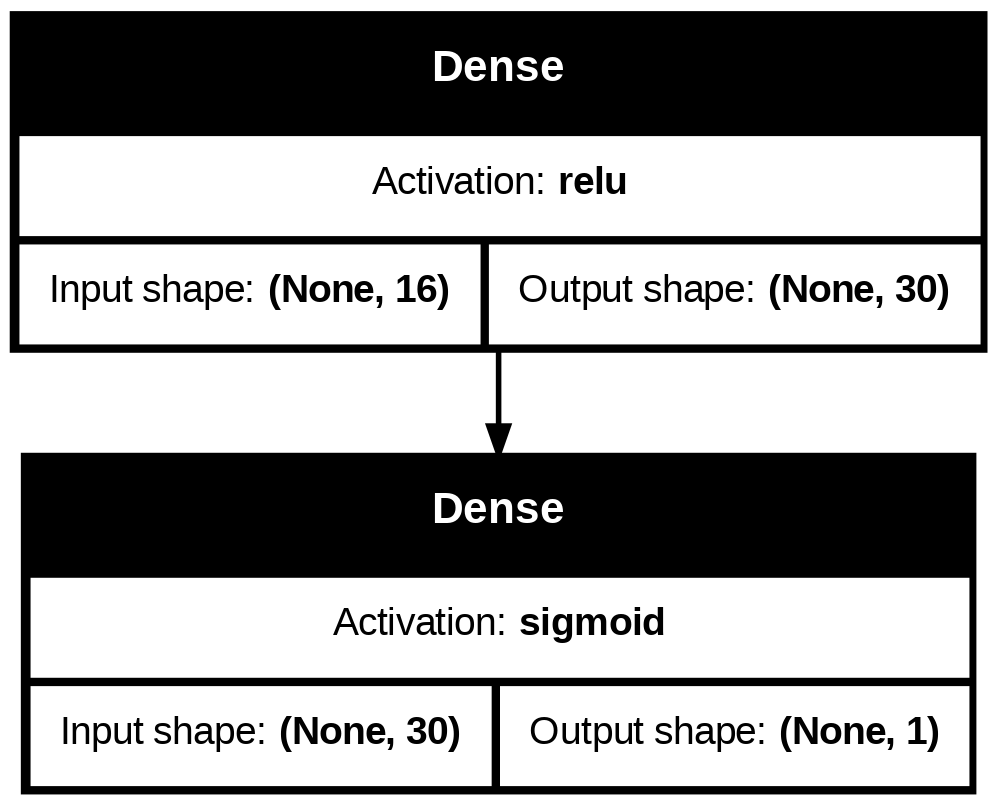

In [9]:
# model = Sequential([
# Input(shape=(16,))
# ,Dense(30, activation='relu')
# ,Dense(1, activation= 'sigmoid')
# ])

model = Sequential()
model.add(Input(shape=(16,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(1, activation= 'sigmoid'))

model.summary()
plot_model(model,show_shapes=True, show_layer_activations=True)

### 4. 모델 실행

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(X, y, epochs=5, batch_size=16) # 학습 결과를 history에 저장

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1638 - loss: 6.3550
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4006 - loss: 1.0185 
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8224 - loss: 0.5523
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8465 - loss: 0.4406 
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8668 - loss: 0.3998 


In [ ]:
history.history

{'accuracy': [0.17234042286872864,
  0.6212766170501709,
  0.8510638475418091,
  0.8510638475418091,
  0.8510638475418091],
 'loss': [4.881708145141602,
  0.7035940885543823,
  0.4670601189136505,
  0.44931426644325256,
  0.44489336013793945]}

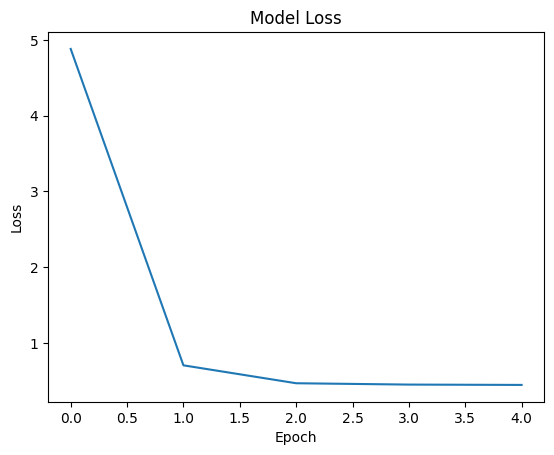

In [ ]:
import matplotlib.pyplot as plt # 손실값 시각화
plt.plot(history.history['loss'])
plt.xlabel('Epoch') # x = 시행횟수
plt.ylabel('Loss') # y = 손실값
plt.title('Model Loss')
plt.show()

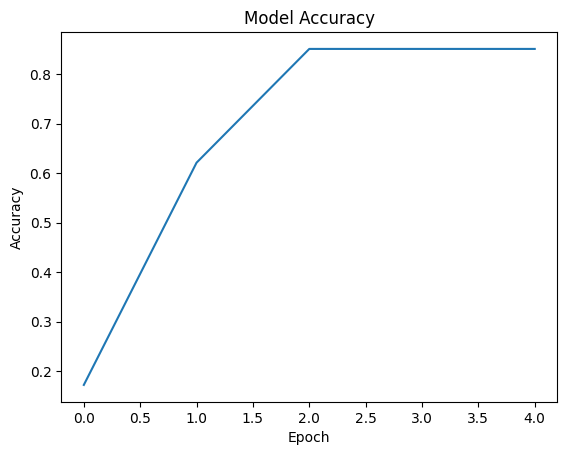

In [ ]:
plt.plot(history.history['accuracy']) # 정확도 시각화
plt.xlabel('Epoch') # x = 시행 횟수
plt.ylabel('Accuracy') # y = 정확도
plt.title('Model Accuracy')
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X, y)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8313 - loss: 0.4842 
Test Loss: 0.4430
Test Accuracy: 0.8511


문제 1 : train, test 데이터셋을 나누는 코드를 추가하고 다시 실행해보세요
- 24번째 셀의 evaluate()의 파라미터값도 추가한 변수 중 테스트 데이터셋으로 변경

문제 2: model2라는 변수에 아래 조건을 만족하는 모델을 저장하고 학습해서 결과를 비교해보세요
- 입력층 동일
- 은닉층1 : 64개의 뉴런, 활성화함수 ReLU 사용
- 은닉층2 : 32개의 뉴런, 활성화함수 ReLU 사용
- 출력층 동일

In [ ]:
!git clone https://github.com/taehojo/data.git

Data_set = np.loadtxt("./data/ThoraricSurgery3.csv", delimiter=",") # 데이터셋 배열 변환
X = Data_set[:,0:16]
y = Data_set[:,16]

In [ ]:
import pandas as pd
df = pd.read_csv('./data/ThoraricSurgery3.csv', header=None)
df.head()

In [25]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(X,y ,test_size=0.2, random_state=42)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577 (2.25 KB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 0 (0.00 B)

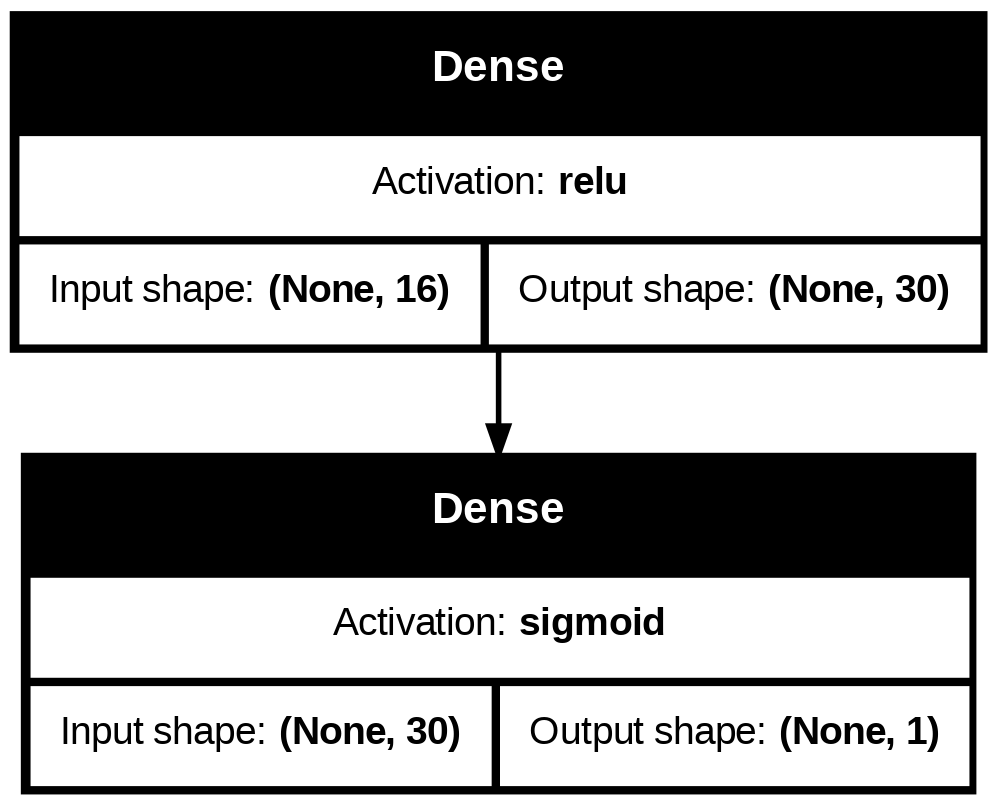

In [14]:
model2 = Sequential()
model2.add(Input(shape=(16,))) # 입력층
model2.add(Dense(32, activation='relu')) # 은닉층
model2.add(Dense(1, activation= 'sigmoid')) # 출력층

model2.summary()
plot_model(model,show_shapes=True, show_layer_activations=True)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

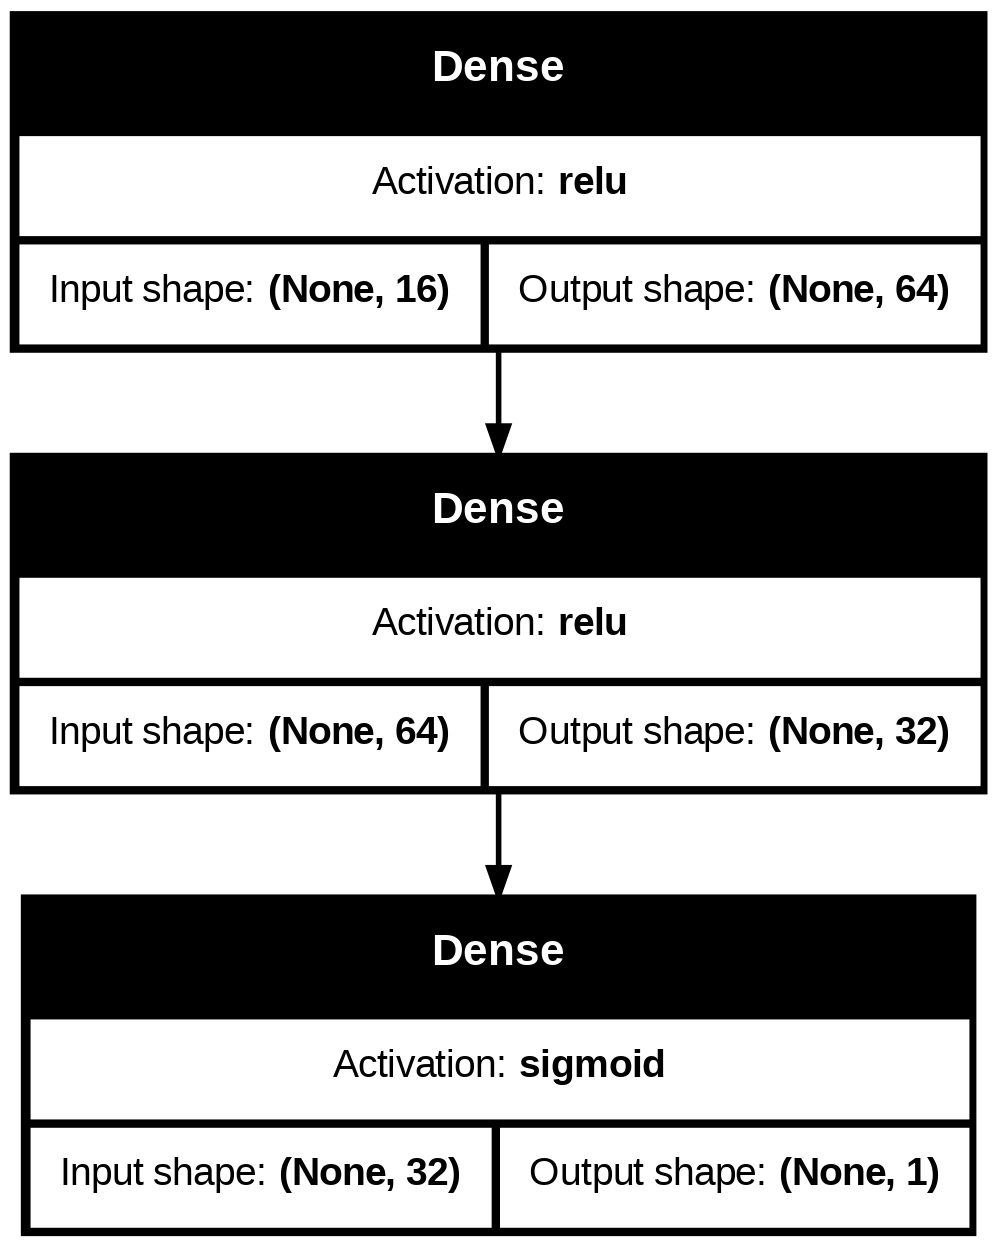

In [23]:
model2 = Sequential()
model2.add(Input(shape=(16,))) # 입력층
model2.add(Dense(64, activation='relu')) # 은닉층
model2.add(Dense(32, activation='relu')) # 은닉층
model2.add(Dense(1, activation= 'sigmoid')) # 출력층

model2.summary()
plot_model(model2,show_shapes=True, show_layer_activations=True)

In [26]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model2.fit(train_input,train_target, epochs=5, batch_size=16) # 학습 결과를 history에 저장

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5619 - loss: 1.0645
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8928 - loss: 0.3641 
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8535 - loss: 0.4341 
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8472 - loss: 0.4291 
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8632 - loss: 0.4072 


In [19]:
history.history

{'accuracy': [0.5085106492042542,
  0.848936140537262,
  0.8510638475418091,
  0.8510638475418091,
  0.8510638475418091],
 'loss': [2.030513048171997,
  0.5227981209754944,
  0.42436331510543823,
  0.4238385856151581,
  0.41901955008506775]}

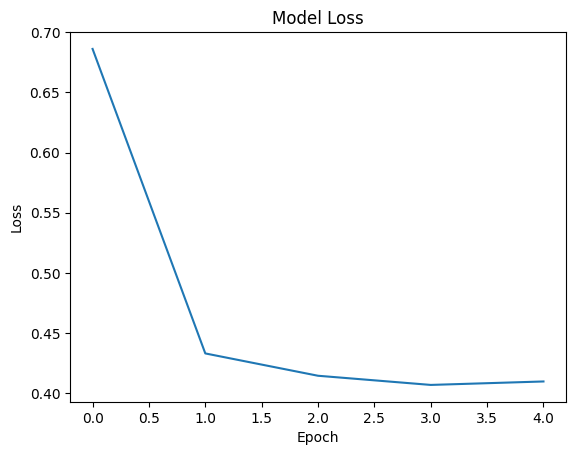

In [28]:
import matplotlib.pyplot as plt # 손실값 시각화
plt.plot(history.history['loss'])
plt.xlabel('Epoch') # x = 시행횟수
plt.ylabel('Loss') # y = 손실값
plt.title('Model Loss')
plt.show()

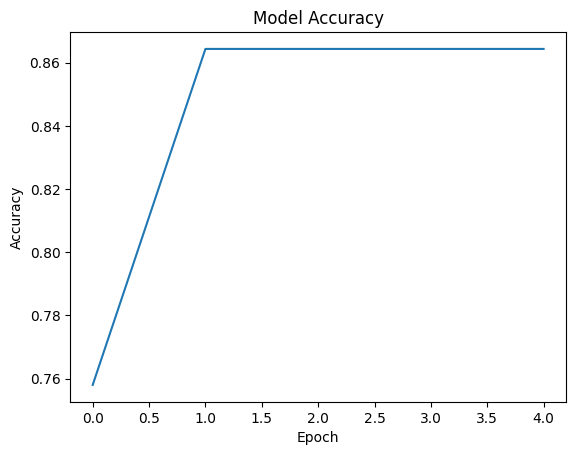

In [29]:
plt.plot(history.history['accuracy']) # 정확도 시각화
plt.xlabel('Epoch') # x = 시행 횟수
plt.ylabel('Accuracy') # y = 정확도
plt.title('Model Accuracy')
plt.show()

In [27]:
loss, accuracy = model2.evaluate(test_input, test_target)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7974 - loss: 0.5526 
Test Loss: 0.5609
Test Accuracy: 0.7979
